# Arranging multiple Axes in a Figure

📄 Source: https://matplotlib.org/stable/users/explain/axes/arranging_axes.html

Usually you want more than one Axes, arranged in a grid. This page covers the tools to use most often.

> *Axes* = the drawing area with data, x/y axis, ticks, labels, title. A *subplot* = an Axes that sits in a grid with others.

## Overview

**Create grid-shaped combinations of Axes**
- `plt.subplots`: the primary function. Creates the figure and a grid of Axes at once, returns an **array** of Axes.
- `plt.subplot_mosaic`: like `subplots`, but Axes can **span** rows/columns, and they come back in a **labelled dict**.
- `SubFigure`: a virtual figure inside a figure, for distinct groups of Axes.

**Underlying tools**
- `GridSpec`: the geometry of the grid (rows, columns, spacing).
- `SubplotSpec`: the location of one subplot in a GridSpec.

**Adding single Axes at a time** (older, less flexible)
- `fig.add_axes([left, bottom, width, height])` in fractions of the figure.
- `plt.subplot` / `fig.add_subplot`: 1-based indexing, inherited from MATLAB.
- `plt.subplot2grid`: 0-based, with slicing.

**Skipped (as planned):** everything under *Low-level and advanced grid methods*.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

print("matplotlib", mpl.__version__)

matplotlib 3.11.2


A simple manual example: a 3 × 2 inch Axes inside a 4 × 3 inch figure. Position is `[left, bottom, width, height]` in figure-normalised units (0 to 1).

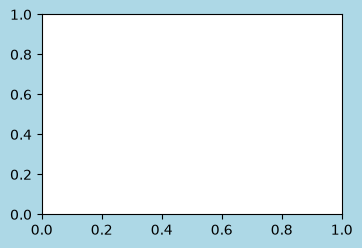

In [2]:
w, h = 4, 3          # figure size in inches
margin = 0.5         # margin in inches
fig = plt.figure(figsize=(w, h), facecolor='lightblue')
ax = fig.add_axes((margin / w, margin / h,                       # left, bottom (as fractions)
                   (w - 2 * margin) / w, (h - 2 * margin) / h))  # width, height (as fractions)

## High-level methods for making grids

### Basic 2x2 grid

`plt.subplots(nrows, ncols)` returns a `Figure` and a 2-D **array** of Axes. Index it as `axs[row, col]`.

Text(0.5, 0.98, 'plt.subplots()')

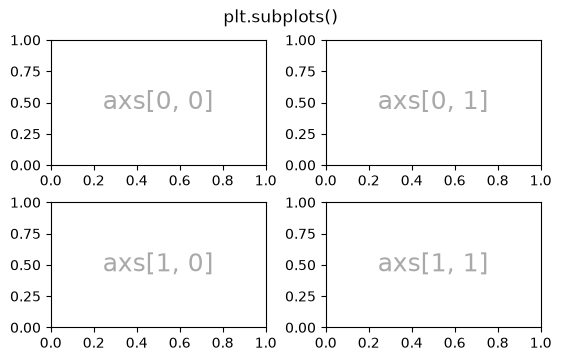

In [3]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(5.5, 3.5),
                        layout="constrained")
# add an artist, in this case a nice label in the middle...
for row in range(2):
    for col in range(2):
        axs[row, col].annotate(f'axs[{row}, {col}]', (0.5, 0.5),
                               transform=axs[row, col].transAxes,   # (0.5, 0.5) = centre of that Axes
                               ha='center', va='center', fontsize=18,
                               color='darkgrey')
fig.suptitle('plt.subplots()')

We'll label a lot of Axes, so wrap that in a helper:

In [4]:
def annotate_axes(ax, text, fontsize=18):
    """Write `text` in grey in the middle of `ax`."""
    ax.text(0.5, 0.5, text, transform=ax.transAxes,
            ha="center", va="center", fontsize=fontsize, color="darkgrey")

The same grid with `subplot_mosaic`: each inner list is a row, each string a column. The result is a **dict**, so the keys can have meaningful names.

Text(0.5, 0.98, 'plt.subplot_mosaic()')

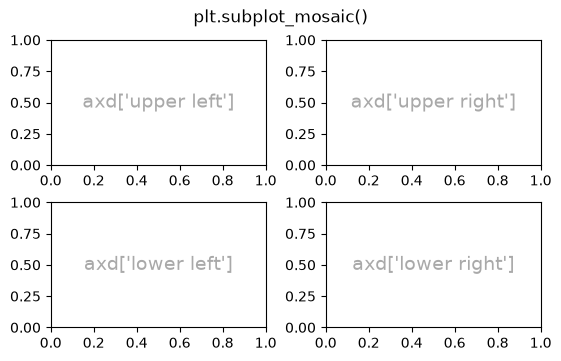

In [5]:
fig, axd = plt.subplot_mosaic([['upper left', 'upper right'],
                               ['lower left', 'lower right']],
                              figsize=(5.5, 3.5), layout="constrained")
for k, ax in axd.items():
    annotate_axes(ax, f'axd[{k!r}]', fontsize=14)
fig.suptitle('plt.subplot_mosaic()')

**My addition for the roadmap (small multiples):** `sharex=True, sharey=True` makes every panel use the same axis limits, so panels can be compared by eye. Loop over `axs.flat` to fill them.

Text(0.5, 0.98, 'Small multiples: same scales, easy to compare')

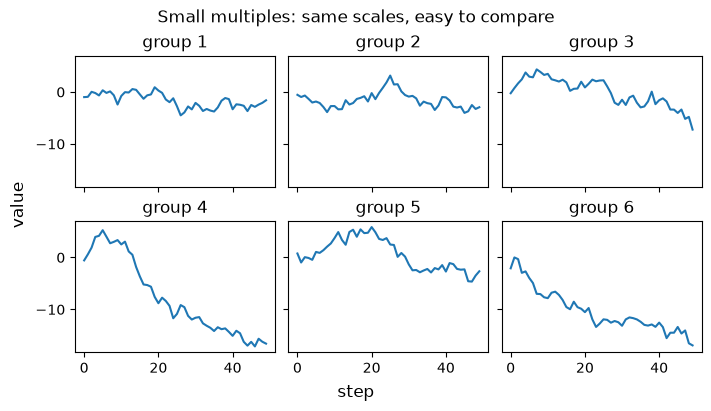

In [6]:
rng = np.random.default_rng(19680801)
fig, axs = plt.subplots(2, 3, figsize=(7, 4), sharex=True, sharey=True, layout="constrained")

for i, ax in enumerate(axs.flat):          # axs.flat walks the 2x3 grid row by row
    y = np.cumsum(rng.normal(size=50))     # one random walk per panel
    ax.plot(y, color="tab:blue")
    ax.set_title(f"group {i + 1}")

fig.supxlabel("step")      # one shared x label for the whole figure
fig.supylabel("value")     # one shared y label
fig.suptitle("Small multiples: same scales, easy to compare")

### Grids of fixed-aspect ratio Axes

Images and maps have a fixed aspect ratio. Fitting the figure **and** keeping the aspect leaves big gaps by default:

Text(0.5, 0.98, 'Fixed aspect Axes')

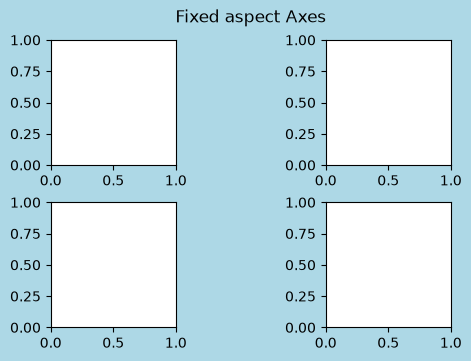

In [7]:
fig, axs = plt.subplots(2, 2, layout="constrained",
                        figsize=(5.5, 3.5), facecolor='lightblue')
for ax in axs.flat:
    ax.set_aspect(1)   # square Axes
fig.suptitle('Fixed aspect Axes')

Text(0.5, 0.98, 'Fixed aspect Axes: compressed')

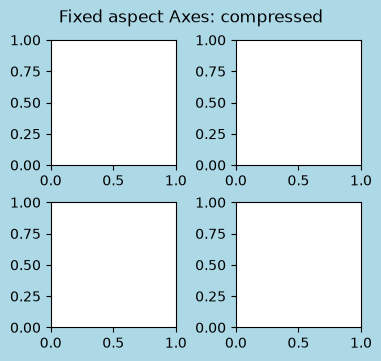

In [8]:
# layout="compressed" closes the gaps for simple grids
fig, axs = plt.subplots(2, 2, layout="compressed", figsize=(5.5, 3.5),
                        facecolor='lightblue')
for ax in axs.flat:
    ax.set_aspect(1)
fig.suptitle('Fixed aspect Axes: compressed')

### Axes spanning rows or columns in a grid

The easiest way: in `subplot_mosaic`, **repeat a key**. `'right'` appears in both rows, so that Axes spans both rows.

Text(0.5, 0.98, 'plt.subplot_mosaic()')

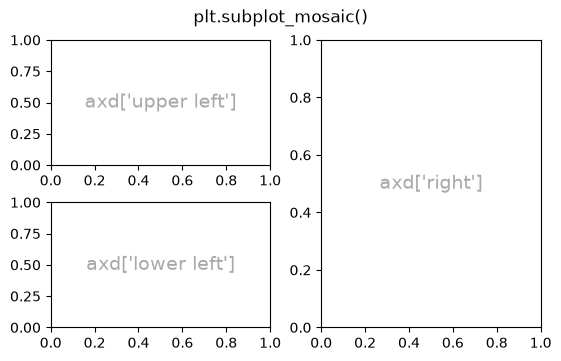

In [9]:
fig, axd = plt.subplot_mosaic([['upper left', 'right'],
                               ['lower left', 'right']],
                              figsize=(5.5, 3.5), layout="constrained")
for k, ax in axd.items():
    annotate_axes(ax, f'axd[{k!r}]', fontsize=14)
fig.suptitle('plt.subplot_mosaic()')

A mosaic can also be written as one string: rows separated by `;` (README example `"AAB;CCB"`):

Text(0.5, 0.98, 'plt.subplot_mosaic("AAB;CCB")')

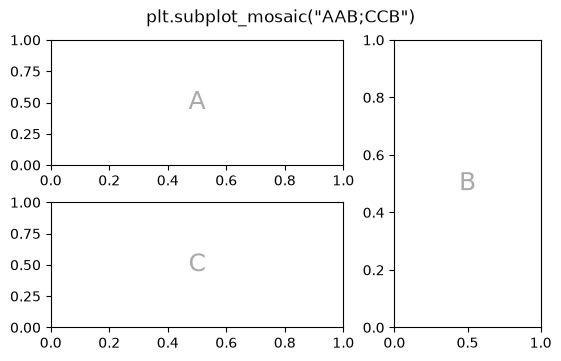

In [10]:
fig, axd = plt.subplot_mosaic("AAB;CCB", figsize=(5.5, 3.5), layout="constrained")
for k, ax in axd.items():
    annotate_axes(ax, k)
fig.suptitle('plt.subplot_mosaic("AAB;CCB")')

### Variable widths or heights in a grid

Both `subplots` and `subplot_mosaic` accept `gridspec_kw` with `width_ratios` and `height_ratios` (and any other GridSpec spacing parameter):

Text(0.5, 0.98, 'plt.subplot_mosaic()')

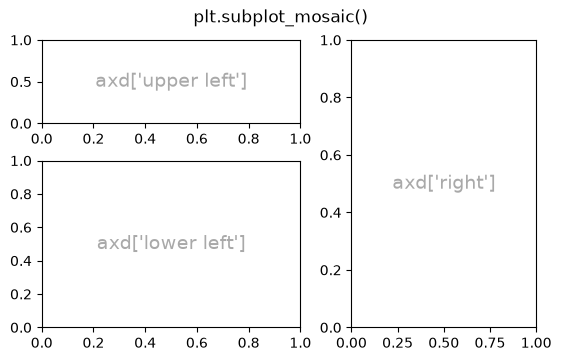

In [11]:
gs_kw = dict(width_ratios=[1.4, 1], height_ratios=[1, 2])   # left column 1.4x wider, bottom row 2x taller
fig, axd = plt.subplot_mosaic([['upper left', 'right'],
                               ['lower left', 'right']],
                              gridspec_kw=gs_kw, figsize=(5.5, 3.5),
                              layout="constrained")
for k, ax in axd.items():
    annotate_axes(ax, f'axd[{k!r}]', fontsize=14)
fig.suptitle('plt.subplot_mosaic()')

### Nested Axes layouts (skim)

For two or more unrelated grids, use `fig.subfigures`. Each subfigure has its own layout (so spines may not line up) and its own `suptitle`, `supxlabel`, `supylabel` and facecolor.

Text(0.02, 0.5, 'ylabel for subfigs[1]')

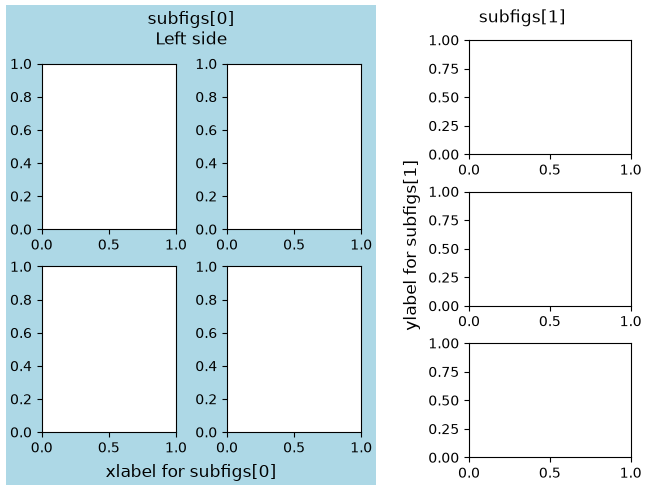

In [12]:
fig = plt.figure(layout="constrained")
subfigs = fig.subfigures(1, 2, wspace=0.07, width_ratios=[1.5, 1.])
axs0 = subfigs[0].subplots(2, 2)                 # a 2x2 grid in the left subfigure
subfigs[0].set_facecolor('lightblue')
subfigs[0].suptitle('subfigs[0]\nLeft side')
subfigs[0].supxlabel('xlabel for subfigs[0]')

axs1 = subfigs[1].subplots(3, 1)                 # a 3x1 grid in the right subfigure
subfigs[1].suptitle('subfigs[1]')
subfigs[1].supylabel('ylabel for subfigs[1]')

`subplot_mosaic` can also nest, using a **list inside the list**. No subfigures here, so no per-group suptitles.

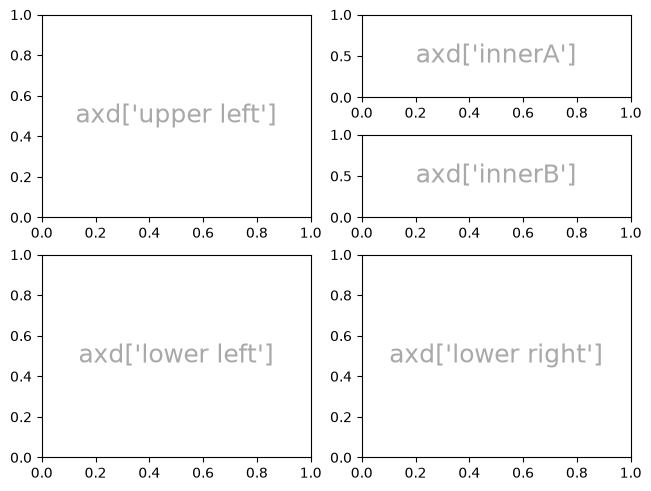

In [13]:
inner = [['innerA'],
         ['innerB']]
outer = [['upper left',  inner],          # the top-right cell is itself a 2-row mosaic
          ['lower left', 'lower right']]

fig, axd = plt.subplot_mosaic(outer, layout="constrained")
for k, ax in axd.items():
    annotate_axes(ax, f'axd[{k!r}]')

## Key takeaways

| I want... | Use |
| :-- | :-- |
| a regular grid | `fig, axs = plt.subplots(r, c, layout="constrained")` → `axs[row, col]`, loop with `axs.flat` |
| small multiples | add `sharex=True, sharey=True` |
| panels that span rows/columns | `plt.subplot_mosaic("AAB;CCB")` → `axd["A"]` |
| unequal sizes | `width_ratios=` / `height_ratios=` (via `gridspec_kw`) |
| a grid of images | `layout="compressed"` |
| independent groups | `fig.subfigures(...)` |